In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn.functional as F
from torchvision import transforms
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler, StableDiffusionPipeline, DiffusionPipeline, ControlNetModel, StableDiffusionControlNetPipeline, DDIMScheduler
from diffusers.optimization import get_scheduler
from torchvision.models import vgg16
from peft import LoraConfig
from tqdm import tqdm
from PIL import Image

device = 'cuda'

c:\Users\Hyunyoung\anaconda3\envs\diffuser-test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# 폴더 경로 설정
dataset_folder = r"C:\Users\Hyunyoung\datasets_diffusion_test_arch"
input_image_dir = os.path.join(dataset_folder, "input")
target_image_dir = os.path.join(dataset_folder, "output")

# 이미지 변환 설정 (전처리)
IMG_SIZE = 256
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # (0,1)->(-1,1) 범위로 정규화
])

# 데이터셋 정의 (로컬 디렉토리에서 이미지를 로드)
class ImagePairDataset(torch.utils.data.Dataset):
    def __init__(self, input_dir, target_dir, file_list, transform=None):
        self.input_dir = input_dir
        self.target_dir = target_dir
        self.file_list = file_list
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        input_image_path = os.path.join(self.input_dir, filename + ".png")
        target_image_path = os.path.join(self.target_dir, filename + ".jpg")

        input_image = Image.open(input_image_path).convert("RGB")
        target_image = Image.open(target_image_path).convert("RGB")

        if self.transform:
            input_image = self.transform(input_image)
            target_image = self.transform(target_image)

        return {"input_image": input_image, "target_image": target_image}

# 확장자를 제거한 파일 이름 목록 생성
input_filenames = {os.path.splitext(f)[0] for f in os.listdir(input_image_dir)}
target_filenames = {os.path.splitext(f)[0] for f in os.listdir(target_image_dir)}

common_filenames = list(input_filenames.intersection(target_filenames))
common_filenames.sort()

if len(common_filenames) == 0:
    print("Error: input 폴더와 output 폴더에 이름이 같은 파일이 없습니다.")
else:
    common_filenames = [f for f in common_filenames]

# Train/Test 데이터를 80/20 비율로 나눔
train_filenames, eval_filenames = train_test_split(common_filenames, test_size=0.2, random_state=42)

# Train/Validation 데이터셋 생성
train_dataset = ImagePairDataset(input_image_dir, target_image_dir, train_filenames, transform=train_transforms)
eval_dataset = ImagePairDataset(input_image_dir, target_image_dir, eval_filenames, transform=train_transforms)

# DataLoader 설정
BATCH_SIZE = 2 
NUM_WORKERS = 0

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

eval_dataloader = torch.utils.data.DataLoader(
    eval_dataset,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

In [6]:
# 모델 설정
PRE_TRAINED_MODEL_NAME = "runwayml/stable-diffusion-v1-5"
CONTROLNET_MODEL_NAME = "lllyasviel/sd-controlnet-scribble"

# 노이즈 스케줄러, 토크나이저, 텍스트 인코더, VAE 모델 설정
noise_scheduler = DDPMScheduler.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="scheduler")
tokenizer = CLIPTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="tokenizer")
text_encoder = CLIPTextModel.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="text_encoder")
vae = AutoencoderKL.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="vae")

# UNet 모델 로드
unet = UNet2DConditionModel.from_pretrained(PRE_TRAINED_MODEL_NAME, subfolder="unet")

# VGG 모델 설정 (피처 추출용)
vgg = vgg16(pretrained=True).features.to(device).eval()  

# LoRA 설정
LORA_RANK = 16
unet_lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_RANK,
    init_lora_weights="gaussian",
    target_modules=["to_k", "to_q", "to_v", "to_out.0"],
)

# LoRA 적용
unet.add_adapter(unet_lora_config)

# ControlNet 모델 로드 및 결합
controlnet = ControlNetModel.from_pretrained(CONTROLNET_MODEL_NAME).to(device)
unet.controlnet = controlnet  # ControlNet을 U-Net에 결합

# 장치로 모델 보내기
text_encoder.to(device)
vae.to(device)
unet.to(device)

# Optimizer 설정
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, unet.parameters()),
    lr=5e-5
)

EPOCHS = 3
lr_scheduler = get_scheduler(
    'linear', optimizer=optimizer, num_warmup_steps=500, num_training_steps=EPOCHS * len(train_dataloader)
)

def perceptual_loss(img1, img2):
    if img1.shape[1] != 3 or img2.shape[1] != 3:  # 수정됨: VGG는 3채널 RGB 이미지를 기대
        raise ValueError("Input to perceptual_loss must have 3 channels (RGB).")
    features1 = vgg(img1)
    features2 = vgg(img2)
    return F.mse_loss(features1, features2)


In [7]:
# 학습 루프
train_losses = []
scaler = torch.amp.GradScaler('cuda')

for epoch in range(EPOCHS):
    unet.train()
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for step, batch in enumerate(progress_bar):
        input_images = batch["input_image"].to(device).to(torch.float32)  # float32로 변환
        target_images = batch["target_image"].to(device).to(torch.float32)  # float32로 변환

        torch.cuda.empty_cache()

        # VAE로 입력 이미지 인코딩
        latents = vae.encode(input_images).latent_dist.sample()
        latents = latents * vae.config.scaling_factor

        # 타겟 이미지도 VAE로 인코딩하여 잠재 벡터로 변환
        target_latents = vae.encode(target_images).latent_dist.sample()
        target_latents = target_latents * vae.config.scaling_factor

        noise = torch.randn_like(latents)
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (latents.shape[0],), device=latents.device)
        timesteps = timesteps.long()

        noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

        text_input = tokenizer(
            ["Blueprint-style input to realistic building output."] * BATCH_SIZE,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=tokenizer.model_max_length
        )
        encoder_hidden_states = text_encoder(text_input.input_ids.to(device))[0]

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            model_pred = unet(noisy_latents, timesteps, encoder_hidden_states=encoder_hidden_states).sample
            decoded_pred = vae.decode(model_pred, return_dict=False)[0]
            decoded_target = vae.decode(target_latents, return_dict=False)[0]

            image_loss = F.mse_loss(decoded_pred, decoded_target)
            perc_loss = perceptual_loss(decoded_pred, decoded_target)  
            noise_loss = F.mse_loss(model_pred.float(), noise.float())
            loss = noise_loss + image_loss + 0.1 * perc_loss

        train_losses.append(loss.item())
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        lr_scheduler.step()

        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = sum(train_losses[-100:]) / len(train_losses[-100:])
    print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {avg_loss:.4f}")

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Learning rate after epoch {epoch+1}: {current_lr:.8f}")

Epoch 1/3:   0%|          | 0/145 [00:00<?, ?it/s]c:\Users\Hyunyoung\anaconda3\envs\diffuser-test\lib\site-packages\diffusers\models\attention_processor.py:2358: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(
Epoch 1/3: 100%|██████████| 145/145 [1:19:09<00:00, 32.75s/it, loss=0.0719]


Epoch [1/3], Train Loss: 0.1109
Learning rate after epoch 1: 0.00001450


Epoch 2/3: 100%|██████████| 145/145 [1:19:29<00:00, 32.89s/it, loss=0.0724]


Epoch [2/3], Train Loss: 0.1049
Learning rate after epoch 2: 0.00002900


Epoch 3/3: 100%|██████████| 145/145 [1:19:57<00:00, 33.09s/it, loss=0.0672]

Epoch [3/3], Train Loss: 0.0907
Learning rate after epoch 3: 0.00004350


In [8]:
# 모델 저장
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,
)
pipeline.save_pretrained("./fine_tuned_model(3)")

Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00, 15.05it/s]


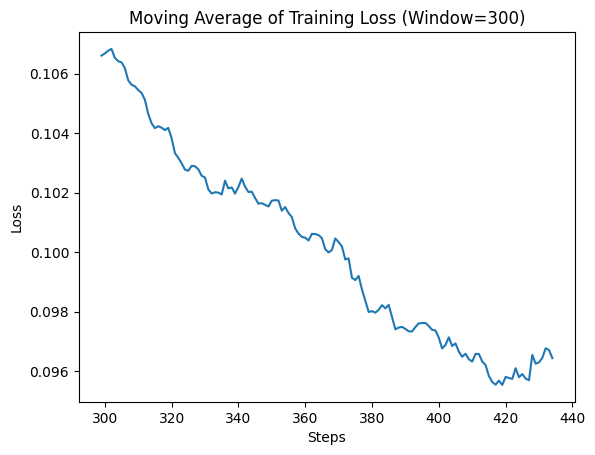

In [9]:
# 손실 추이를 저장하는 부분
losses_sr = pd.Series(train_losses)
loss_mv = losses_sr.rolling(window=300).mean()

# 손실 이동 평균 그래프 그리기
plt.plot(loss_mv)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Moving Average of Training Loss (Window=300)')
plt.show()

In [53]:
# 이미지 파일을 열고 텐서로 변환하는 함수
def load_image(image_path, transform):
    image = Image.open(image_path).convert("RGB")
    return transform(image).unsqueeze(0).to(device)

# 이미지 경로 설정
input_image_path = r"C:\Users\Hyunyoung\datasets_diffusion_test_arch\test_input.png" 

# 이미지 로드 및 전처리
transform = transforms.Compose([
    transforms.Resize((256, 256)),  
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # (-1, 1) 범위로 정규화
])

# 입력 이미지를 텐서로 변환
input_image_tensor = load_image(input_image_path, transform)

# Stable Diffusion Pipeline 설정 및 모델 연결
pipeline = StableDiffusionPipeline.from_pretrained(
    PRE_TRAINED_MODEL_NAME,
    text_encoder=text_encoder,
    vae=vae,
    unet=unet,  # 미세 조정된 UNet
)

pipeline.to(device)

# output 이미지를 저장할 새로운 폴더 경로 생성
output_image_dir = os.path.join(dataset_folder, "generated_output")  
os.makedirs(output_image_dir, exist_ok=True)  # 폴더가 없을 경우 생성

# 결과 이미지를 저장하는 함수
def save_generated_image(image, filename, output_dir=output_image_dir): 
    # 확장자가 없으면 기본 확장자 .png를 추가
    if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):  
        filename += ".png"
    
    save_path = os.path.join(output_dir, filename)
    image.save(save_path)

# 이미지를 VAE로 인코딩하여 잠재 벡터 생성
with torch.no_grad():
    latents = vae.encode(input_image_tensor).latent_dist.sample()  # 이미지를 잠재 벡터로 인코딩
    latents = latents * vae.config.scaling_factor  # VAE scaling factor 적용


# 이미지 생성 및 저장 (inference)
lora_scale = 0.9  # LoRA 적용 비율
pipeline_output = pipeline(
    prompt=[""],  
    latents=latents, 
    num_inference_steps=20,  
    cross_attention_kwargs={"scale": lora_scale},  
    generator=torch.manual_seed(101)  
)

# 잠재 벡터를 VAE를 통해 이미지로 디코딩
with torch.no_grad():
    decoded_image = vae.decode(latents, return_dict=False)[0] 

# 디코딩된 이미지를 저장
decoded_image_pil = transforms.ToPILImage()(decoded_image.squeeze(0))  # 텐서를 PIL 이미지로 변환
save_generated_image(decoded_image_pil, "vae_decoded_image.png")  # 이미지 저장

100%|██████████| 20/20 [00:38<00:00,  1.95s/it]
